# Laboratorio 01: Cotizaciones óptimas de un formador de mercado

Implementación del modelo de Copeland y Galai (1983) para determinar las cotizaciones Bid y Ask que maximizan la utilidad esperada de un formador de mercado ante traders informados y traders de liquidez.

Este notebook utiliza las funciones definidas en `src/`. No contiene la lógica del modelo ni del simulador.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.model import optimize_quotes, sensitivity_analysis
from src.plots import (
    plot_cumulative_inventory,
    plot_cumulative_pnl,
    plot_execution_probability,
    plot_monte_carlo_histogram,
    plot_sensitivity,
)
from src.simulation import run_monte_carlo, simulate_trades

SEED = 42
np.random.seed(SEED)

## 1. Cotizaciones óptimas

El modelo maximiza la utilidad esperada, considerando las ganancias frente a traders de liquidez y las pérdidas provocadas por selección adversa.

In [2]:
optimal = optimize_quotes()

optimal_results = pd.DataFrame(
    {
        "Métrica": [
            "Bid óptimo",
            "Ask óptimo",
            "Spread óptimo",
            "Utilidad esperada",
        ],
        "Valor": [
            optimal["bid"],
            optimal["ask"],
            optimal["spread"],
            optimal["expected_profit"],
        ],
    }
)

optimal_results.round(2)

,Métrica,Valor
0,Bid óptimo,16.45
1,Ask óptimo,23.43
2,Spread óptimo,6.98
3,Utilidad esperada,0.84


La cotización óptima presenta un spread estrictamente positivo porque el formador de mercado necesita compensar las pérdidas esperadas frente a traders informados.

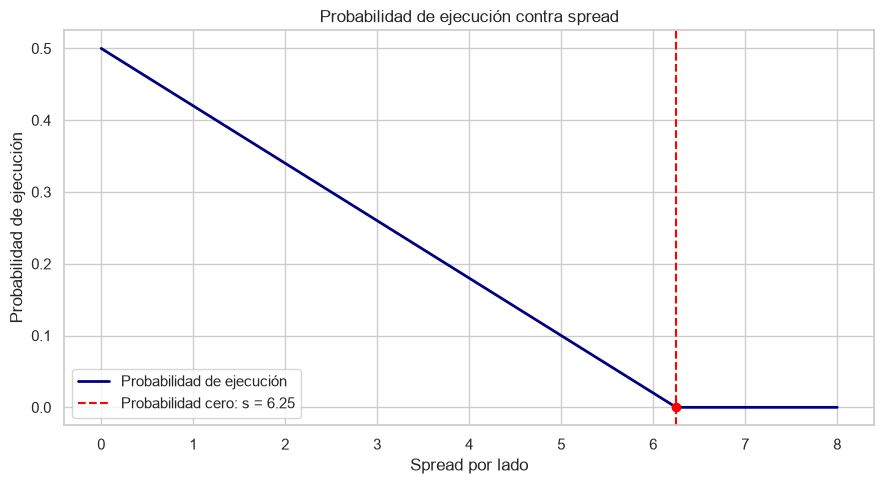

In [3]:
plot_execution_probability()
plt.show()

## 2. Simulación de 10,000 trades

Se comparan tres regímenes de cotización:

- **Óptimo:** cotizaciones obtenidas mediante la maximización de la utilidad.
- **Estrecho:** Bid de 19.75 y Ask de 20.05.
- **Amplio:** Bid de 18.40 y Ask de 21.40.

Los resultados representan rentabilidad por trade ejecutado y no rentabilidad por unidad de tiempo.

In [4]:
regimes = {
    "optimal": {
        "bid": optimal["bid"],
        "ask": optimal["ask"],
    },
    "tight": {
        "bid": 19.75,
        "ask": 20.05,
    },
    "wide": {
        "bid": 18.40,
        "ask": 21.40,
    },
}

simulations = {
    regime: simulate_trades(
        bid=quotes["bid"],
        ask=quotes["ask"],
        n_trades=10_000,
        seed=SEED + index,
    )
    for index, (regime, quotes) in enumerate(regimes.items())
}

In [5]:
simulation_summary = pd.DataFrame(
    [
        {
            "Régimen": regime.capitalize(),
            "P&L final": trades["cumulative_pnl"].iloc[-1],
            "Inventario final": trades["cumulative_inventory"].iloc[-1],
            "Trades informados": (
                trades["trader_type"] == "informed"
            ).sum(),
            "Trades de liquidez": (
                trades["trader_type"] == "liquidity"
            ).sum(),
        }
        for regime, trades in simulations.items()
    ]
)

simulation_summary.round(2)

,Régimen,P&L final,Inventario final,Trades informados,Trades de liquidez
0,Optimal,18526.93,-246,3464,6536
1,Tight,-10703.64,-110,5620,4380
2,Wide,-144.00,-264,4911,5089


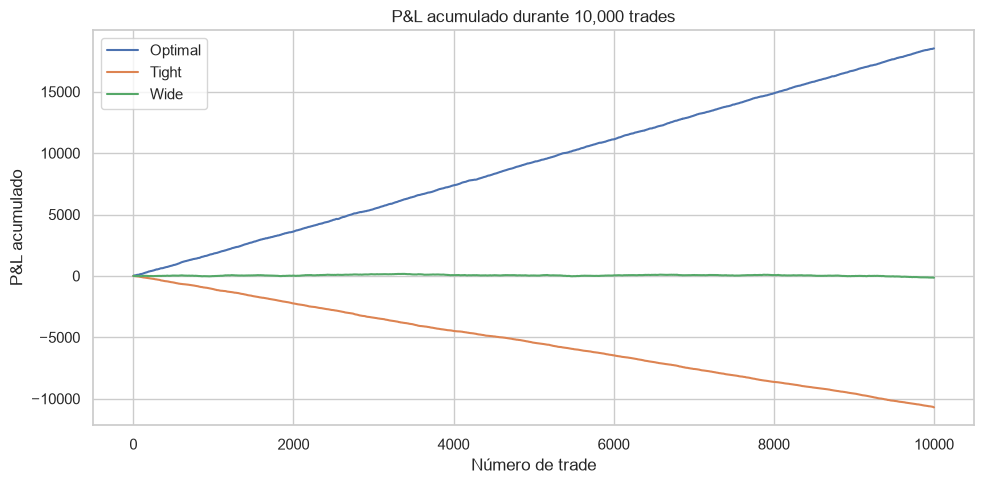

In [6]:
plot_cumulative_pnl(simulations)
plt.show()

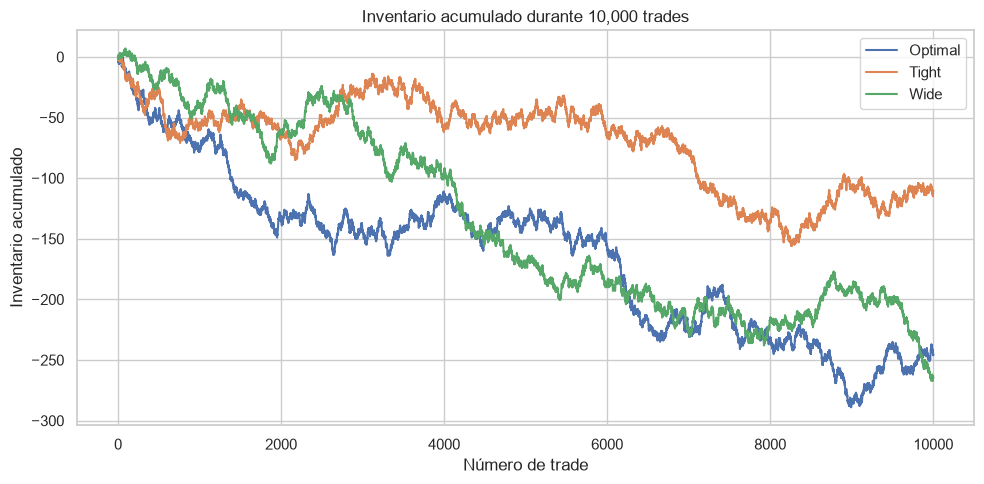

In [7]:
plot_cumulative_inventory(simulations)
plt.show()

### Interpretación

El régimen estrecho queda altamente expuesto a selección adversa. Aunque sus cotizaciones generan mayor facilidad de ejecución, la ganancia obtenida frente a traders de liquidez no es suficiente para compensar las pérdidas frente a traders informados.

El régimen óptimo mantiene un spread suficientemente amplio para compensar ese costo y alcanza el mayor P&L acumulado. El régimen amplio reduce el efecto de la selección adversa, pero su rentabilidad por trade es considerablemente menor que la del régimen óptimo.

El inventario representa las unidades acumuladas por el formador de mercado. Un desbalance elevado lo expone a movimientos posteriores del precio, riesgo que este modelo no incorpora porque valora las operaciones usando un precio de referencia fijo.

## 3. Análisis Monte Carlo

Para evaluar la estabilidad de los resultados se realizan 1,000 corridas independientes de 1,000 trades para cada régimen. Se calcula el P&L promedio, su desviación estándar y la proporción de corridas con P&L final negativo.

In [8]:
monte_carlo_results, monte_carlo_summary = run_monte_carlo(
    regimes=regimes,
    n_runs=1_000,
    trades_per_run=1_000,
    base_seed=1_000,
)

monte_carlo_summary.round(4)

,regime,mean_pnl,std_pnl,loss_probability
0,optimal,1866.4356,72.2748,0.000
1,tight,-1067.1911,49.5757,1.000
2,wide,-35.2276,56.4995,0.744


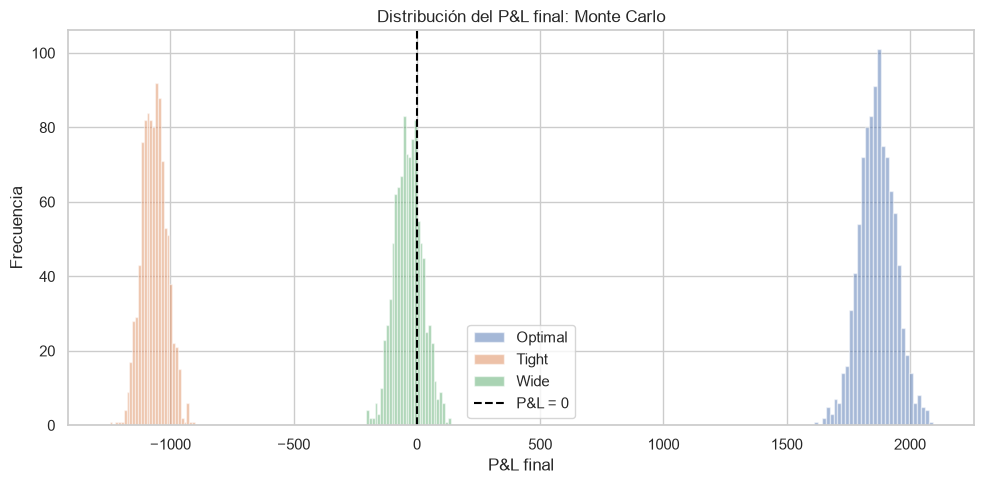

In [9]:
plot_monte_carlo_histogram(monte_carlo_results)
plt.show()

### Interpretación de Monte Carlo

El régimen óptimo obtiene un P&L promedio positivo y una probabilidad de pérdida de 0%. El régimen estrecho presenta pérdidas en 100% de las corridas, confirmando que un spread reducido no compensa el costo de operar contra traders informados.

El régimen amplio presenta resultados cercanos a cero, pero mantiene una probabilidad de pérdida elevada. Esto demuestra que ampliar el spread protege contra selección adversa, aunque hacerlo de manera excesiva no necesariamente maximiza la rentabilidad.

## 4. Sensibilidad a la proporción de traders informados

Se repite la optimización para proporciones de traders informados de 10%, 40% y 70%. La teoría predice que una mayor presencia de información privada obliga al formador de mercado a ampliar sus cotizaciones.

In [10]:
sensitivity_results = pd.DataFrame(
    sensitivity_analysis(pi_values=(0.1, 0.4, 0.7))
)

sensitivity_results.round(4)

,pi_informed,bid,ask,spread,expected_profit
0,0.1,16.7088,23.1065,6.3977,1.3787
1,0.4,16.4517,23.4276,6.9759,0.8403
2,0.7,16.0070,24.0008,7.9938,0.3366


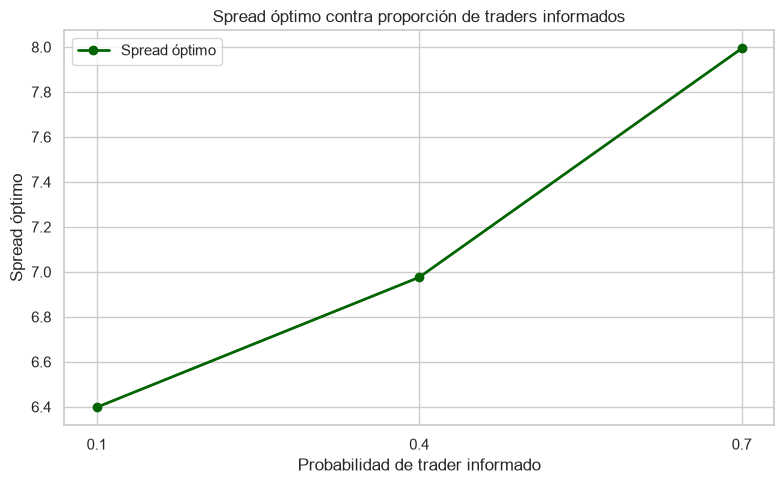

In [11]:
plot_sensitivity(sensitivity_results)
plt.show()

### Interpretación de la sensibilidad

El spread óptimo aumenta de aproximadamente 6.40 cuando la proporción informada es 10%, a 6.98 con 40% y a 7.99 con 70%. El resultado coincide con la predicción teórica: cuanto mayor es la probabilidad de enfrentar a un trader informado, mayor debe ser la compensación exigida por el formador de mercado.

Al mismo tiempo, la utilidad esperada disminuye conforme aumenta la presencia informada, pasando aproximadamente de 1.38 a 0.34. Esto muestra que ampliar el spread reduce el costo de selección adversa, pero no elimina completamente el efecto negativo de la información privada.

## 5. Comparación cuantitativa y conclusiones

In [12]:
comparison = pd.DataFrame(
    [
        {
            "Régimen": regime.capitalize(),
            "Ganancia con liquidez": trades.loc[
                trades["trader_type"] == "liquidity",
                "pnl",
            ].sum(),
            "Pérdida con informados": trades.loc[
                trades["trader_type"] == "informed",
                "pnl",
            ].sum(),
            "P&L total": trades["pnl"].sum(),
            "Inventario final": trades[
                "cumulative_inventory"
            ].iloc[-1],
            "Máximo desbalance absoluto": trades[
                "cumulative_inventory"
            ].abs().max(),
        }
        for regime, trades in simulations.items()
    ]
)

comparison.round(2)

,Régimen,Ganancia con liquidez,Pérdida con informados,P&L total,Inventario final,Máximo desbalance absoluto
0,Optimal,22792.2,-4265.27,18526.93,-246,289
1,Tight,657.0,-11360.64,-10703.64,-110,156
2,Wide,7633.5,-7777.50,-144.00,-264,267


### Respuestas a las preguntas de análisis

**1. ¿Por qué los traders informados generan la necesidad de un spread?**

En el régimen estrecho, el formador de mercado ganó 657.00 frente a traders de liquidez, pero perdió 11,360.64 frente a traders informados. Esto produjo un P&L total de -10,703.64. Por lo tanto, un spread de solamente 0.30 no genera ingresos suficientes para compensar el costo de selección adversa.

**2. ¿Cómo cambia el costo de selección adversa al ampliar el spread?**

La pérdida frente a traders informados fue de 11,360.64 en el régimen estrecho, 7,777.50 en el amplio y 4,265.27 en el óptimo. La magnitud de la pérdida disminuye conforme las cotizaciones se alejan del precio de referencia, porque se reducen las oportunidades rentables de los traders informados.

**3. ¿Cuál régimen acumula el mayor desbalance de inventario?**

En esta trayectoria simulada, el régimen óptimo alcanzó el mayor desbalance absoluto, con 289 unidades. El régimen amplio alcanzó 267 y el estrecho 156. Este resultado depende de la secuencia aleatoria de compras y ventas, por lo que no implica que el régimen óptimo siempre genere más inventario. En un mercado real, el desbalance expone al formador de mercado al riesgo de que el precio cambie mientras mantiene una posición acumulada. El modelo no incorpora este riesgo ni ajusta dinámicamente las cotizaciones según el inventario.

**4. ¿Cómo cambia el spread óptimo al variar la proporción informada?**

El spread óptimo aumentó de 6.40 con una proporción informada de 10%, a 6.98 con 40% y a 7.99 con 70%. Esto coincide con la teoría: una mayor probabilidad de selección adversa exige mayor compensación por operación.

**5. Limitaciones del modelo**

1. El precio de referencia permanece fijo y no evoluciona durante la simulación.
2. El modelo no penaliza el inventario ni modifica el Bid y Ask conforme se acumulan posiciones.
3. No incluye comisiones, latencia, prioridad en la fila de órdenes ni competencia entre formadores de mercado.
4. La simulación completa un número fijo de trades ejecutados, por lo que mide rentabilidad por trade y no por unidad de tiempo. Un spread amplio puede verse favorecido aunque en un mercado real tarde mucho más en ejecutarse.

### Nota técnica sobre el caso sin traders informados

Para una ganancia por lado igual a

\[
g(s)=(0.50-0.08s)s,
\]

la condición de primer orden es

\[
g'(s)=0.50-0.16s=0,
\]

por lo que el máximo ocurre en \(s^*=3.125\). El valor \(6.25=0.50/0.08\) indicado en los lineamientos corresponde al punto donde la probabilidad de ejecución llega a cero, no al máximo de la ganancia.